# Στατιστική Μηχανική Μάθηση - Σγουράκη Γεωργία-Ναταλία 2828

### **Θέμα Εργασίας:** Πρόβλεψη Εγκατάλειψης Σπουδών Φοιτητών

 # 1. Εισαγωγή βιβλιοθηκών



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 1.1 Περιγραφή προβλήματος και δεδομένων
Το πρόβλημα είναι πρόβλημα **δυαδικής ταξινόμησης**. Στόχος είναι η πρόβλεψη της μεταβλητής `Dropout`, όπου `0` σημαίνει ότι ο φοιτητής παραμένει στις σπουδές του και `1` σημαίνει ότι εγκαταλείπει.

Το dataset είναι συνθετικό και περιέχει 10.000 εγγραφές και 19 στήλες. Από αυτές, η `Student_ID` αφαιρείται γιατί είναι αναγνωριστικό και δεν περιέχει χρήσιμη πληροφορία πρόβλεψης. Η μεταβλητή στόχος είναι η `Dropout`, ενώ τα υπόλοιπα χαρακτηριστικά περιγράφουν δημογραφικά, ακαδημαϊκά και κοινωνικοοικονομικά στοιχεία των φοιτητών.

Παρατηρείται ανισορροπία κλάσεων: περίπου 76.5% των φοιτητών ανήκουν στην κλάση παραμονής και 23.5% στην κλάση εγκατάλειψης. Για αυτό χρησιμοποιούνται stratified split, `StratifiedKFold` και `class_weight='balanced'` στα μοντέλα που το υποστηρίζουν.


## Βασικά Στατιστικά Στοιχεία

In [6]:
df = pd.read_csv("student_dropout_dataset.csv")

print("Σχήμα dataset:", df.shape)

print("\nΠρώτες γραμμές:")
display(df.head())

print("\nΤύποι δεδομένων:")
print(df.dtypes)

print("\nΕλλιπείς τιμές ανά στήλη:")
print(df.isna().sum())

print("\nΒασικά στατιστικά:")
display(df.describe().round(2))

print("\nΚατανομή μεταβλητής στόχου:")
print(df["Dropout"].value_counts())

print("\nΠοσοστά μεταβλητής στόχου:")
print((df["Dropout"].value_counts(normalize=True) * 100).round(2))

Σχήμα dataset: (10000, 19)

Πρώτες γραμμές:


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0



Τύποι δεδομένων:
Student_ID                 int64
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
CGPA                     float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

Ελλιπείς τιμές ανά στήλη:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship             

,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00,10000.00,9500.00,9500.00,10000.00,10000.00,10000.00,9500.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,21.03,38377.25,4.01,81.74,1.80,30.18,5.51,2.31,2.30,2.30,0.24
std,2886.90,2.14,20496.23,1.30,8.22,1.34,11.92,1.77,1.06,1.07,1.07,0.42
min,1.00,17.00,25000.00,0.50,38.20,0.00,5.00,1.00,0.00,0.00,0.00,0.00
25%,2500.75,19.50,25000.00,3.16,76.40,1.00,21.90,4.30,1.55,1.52,1.52,0.00
50%,5000.50,21.00,29740.50,4.00,81.80,2.00,30.20,5.50,2.35,2.35,2.35,0.00
75%,7500.25,22.50,44520.00,4.87,87.30,3.00,38.40,6.70,3.12,3.15,3.15,0.00
max,10000.00,29.60,316601.00,8.98,100.00,8.00,74.90,10.00,4.00,4.00,4.00,1.00



Κατανομή μεταβλητής στόχου:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Ποσοστά μεταβλητής στόχου:
Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64


## EDA - Κατανομή Μεταβλητής Στόχου

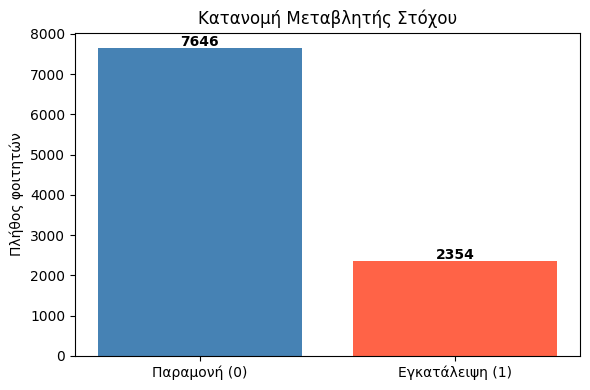

In [7]:
target_counts = df["Dropout"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["Παραμονή (0)", "Εγκατάλειψη (1)"],
    target_counts.values,
    color=["steelblue", "tomato"]
)

plt.title("Κατανομή Μεταβλητής Στόχου")
plt.ylabel("Πλήθος φοιτητών")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 50, str(value), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## EDA - Κατανομές βασικών χαρακτηριστικών ανά κλάση


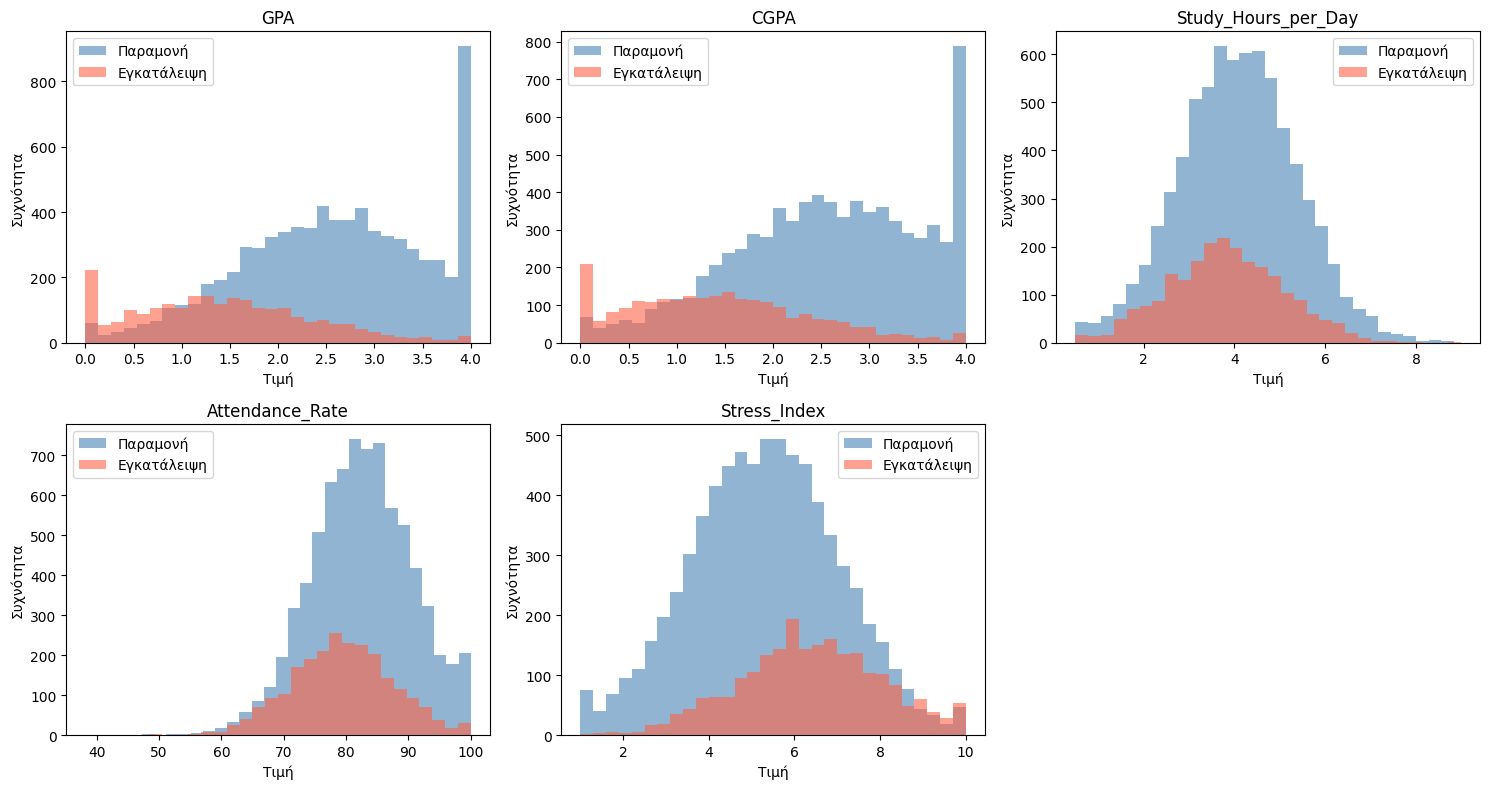

In [8]:
key_features = [
    "GPA",
    "CGPA",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Stress_Index"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    for cls, color, label in [
        (0, "steelblue", "Παραμονή"),
        (1, "tomato", "Εγκατάλειψη")
    ]:
        values = df.loc[df["Dropout"] == cls, feature].dropna()
        axes[i].hist(values, bins=30, alpha=0.6, color=color, label=label)

    axes[i].set_title(feature)
    axes[i].set_xlabel("Τιμή")
    axes[i].set_ylabel("Συχνότητα")
    axes[i].legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()

## EDA - Συσχετίσεις αριθμητικών χαρακτηριστικών


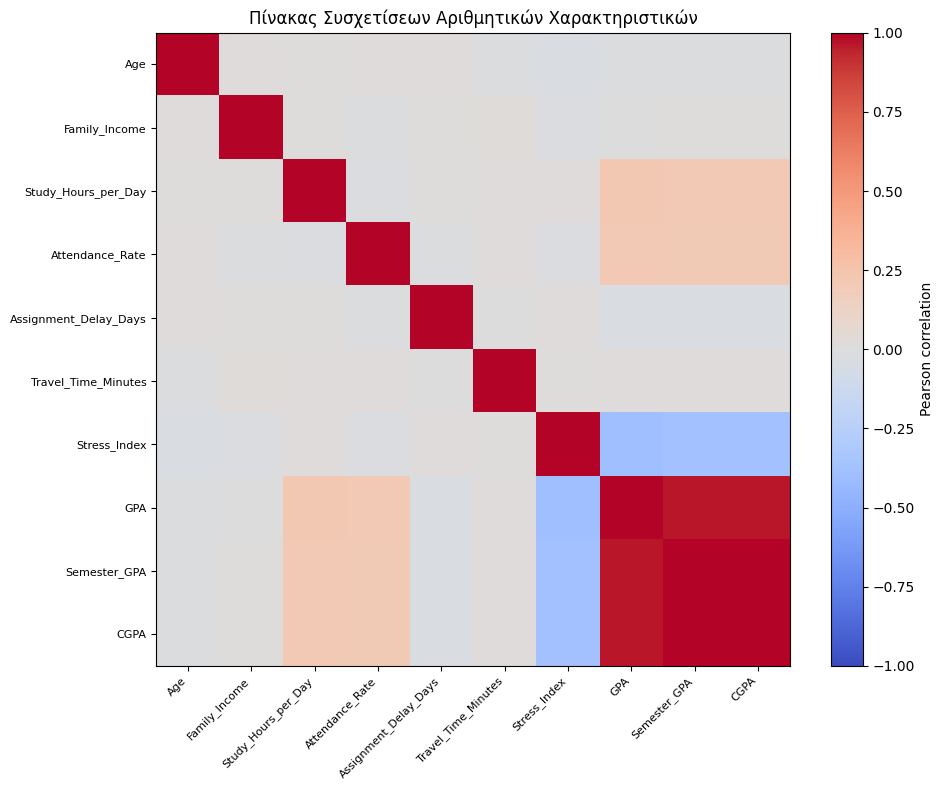

In [9]:
numeric_df = df.select_dtypes(include=[np.number]).drop(
    columns=["Student_ID", "Dropout"]
)

corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

ax.set_title("Πίνακας Συσχετίσεων Αριθμητικών Χαρακτηριστικών")

plt.tight_layout()
plt.show()

# 1.2 Προεπεξεργασία Δεδομένων


In [10]:
X = df.drop(columns=["Student_ID", "Dropout"])
y = df["Dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train set:", X_train.shape)
print("Test set :", X_test.shape)

print("\nΑναλογία Dropout στο train:", round(y_train.mean(), 4))
print("Αναλογία Dropout στο test :", round(y_test.mean(), 4))

Train set: (8000, 17)
Test set : (2000, 17)

Αναλογία Dropout στο train: 0.2354
Αναλογία Dropout στο test : 0.2355


## Ορισμός αριθμητικών και κατηγορικών στηλών


In [11]:
num_features = [
    "Age",
    "Family_Income",
    "Study_Hours_per_Day",
    "Attendance_Rate",
    "Assignment_Delay_Days",
    "Travel_Time_Minutes",
    "Stress_Index",
    "GPA",
    "Semester_GPA",
    "CGPA"
]

cat_features = [
    "Gender",
    "Internet_Access",
    "Part_Time_Job",
    "Scholarship",
    "Semester",
    "Department",
    "Parental_Education"
]

print("Αριθμητικά χαρακτηριστικά:")
print(num_features)

print("\nΚατηγορικά χαρακτηριστικά:")
print(cat_features)

Αριθμητικά χαρακτηριστικά:
['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

Κατηγορικά χαρακτηριστικά:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


## Pipeline προεπεξεργασίας με ColumnTransformer


In [12]:
def make_onehot_encoder(**kwargs):
    try:
        return OneHotEncoder(sparse_output=False, **kwargs)
    except TypeError:
        return OneHotEncoder(sparse=False, **kwargs)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", make_onehot_encoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_features),
    ("cat", categorical_transformer, cat_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Family_Income', 'Study_Hours_per_Day',
                                  'Attendance_Rate', 'Assignment_Delay_Days',
                                  'Travel_Time_Minutes', 'Stress_Index', 'GPA',
                                  'Semester_GPA', 'CGPA']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'Internet_Access', 'Part_Time_Job',
                                  'Scholarship', 'Semester', 'Department',
                                  'Parental_Education'])])

# 1.3 Επιλογή και υλοποίηση μοντέλων


## Θεωρητική αιτιολόγηση επιλογής μοντέλων

Επιλέγονται τρία μοντέλα από την ύλη του μαθήματος:

1. **Logistic Regression**: γραμμικό μοντέλο ταξινόμησης που εκτιμά πιθανότητες για τη θετική κλάση. Επιλέγεται ως ισχυρό και ερμηνεύσιμο baseline. Χρησιμοποιείται `class_weight='balanced'` λόγω ανισορροπίας κλάσεων.

2. **Gaussian Naive Bayes**: πιθανοτικό μοντέλο που βασίζεται στην υπόθεση ανεξαρτησίας χαρακτηριστικών και Gaussian κατανομής για τα αριθμητικά χαρακτηριστικά. Επιλέγεται επειδή είναι απλό, γρήγορο και διδαγμένο στο μάθημα.

3. **Random Forest**: ensemble μοντέλο που συνδυάζει πολλά decision trees. Επιλέγεται επειδή μπορεί να μοντελοποιήσει μη γραμμικές σχέσεις. Χρησιμοποιείται `class_weight='balanced'`, αλλά ελέγχεται προσεκτικά για overfitting.


In [13]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

pipe_nb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", GaussianNB())
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# 1.4 Εκπαίδευση και ρύθμιση υπερπαραμέτρων

## Cross-validation strategy


In [14]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

## GridSearchCV - Logistic Regression


In [15]:
param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100]
}

gs_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gs_lr.fit(X_train, y_train)

print("Logistic Regression")
print("Best parameters:", gs_lr.best_params_)
print("Best CV ROC-AUC:", round(gs_lr.best_score_, 4))

best_lr = gs_lr.best_estimator_

Logistic Regression
Best parameters: {'clf__C': 0.1}
Best CV ROC-AUC: 0.8212


## GridSearchCV - Gaussian Naive Bayes


In [16]:
param_grid_nb = {
    "clf__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

gs_nb = GridSearchCV(
    estimator=pipe_nb,
    param_grid=param_grid_nb,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gs_nb.fit(X_train, y_train)

print("Gaussian Naive Bayes")
print("Best parameters:", gs_nb.best_params_)
print("Best CV ROC-AUC:", round(gs_nb.best_score_, 4))

best_nb = gs_nb.best_estimator_

Gaussian Naive Bayes
Best parameters: {'clf__var_smoothing': 1e-12}
Best CV ROC-AUC: 0.8133


## RandomizedSearchCV - Random Forest


In [17]:
param_dist_rf = {
    "clf__n_estimators": [50, 100, 150],
    "clf__max_depth": [5, 10, 20],
    "clf__min_samples_leaf": [1, 5, 10],
    "clf__max_features": ["sqrt"]
}

rs_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist_rf,
    n_iter=8,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rs_rf.fit(X_train, y_train)

print("Random Forest")
print("Best parameters:", rs_rf.best_params_)
print("Best CV ROC-AUC:", round(rs_rf.best_score_, 4))

best_rf = rs_rf.best_estimator_

Random Forest
Best parameters: {'clf__n_estimators': 150, 'clf__min_samples_leaf': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
Best CV ROC-AUC: 0.812


# 1.5 Αξιολόγηση Μοντέλων


Logistic Regression
Accuracy : 0.7430
Precision: 0.4717
Recall   : 0.7622
F1-score : 0.5828
ROC-AUC  : 0.8203

Classification Report:
                 precision    recall  f1-score   support

   Παραμονή (0)       0.91      0.74      0.81      1529
Εγκατάλειψη (1)       0.47      0.76      0.58       471

       accuracy                           0.74      2000
      macro avg       0.69      0.75      0.70      2000
   weighted avg       0.81      0.74      0.76      2000



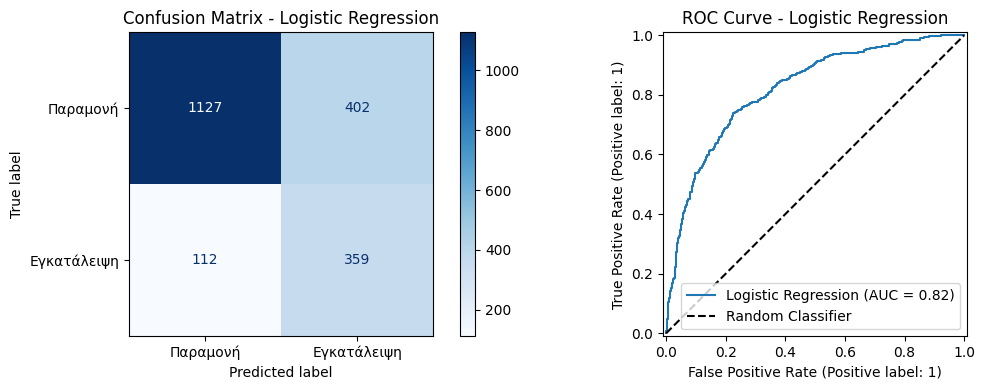

Gaussian Naive Bayes
Accuracy : 0.7780
Precision: 0.5221
Recall   : 0.6773
F1-score : 0.5896
ROC-AUC  : 0.8126

Classification Report:
                 precision    recall  f1-score   support

   Παραμονή (0)       0.89      0.81      0.85      1529
Εγκατάλειψη (1)       0.52      0.68      0.59       471

       accuracy                           0.78      2000
      macro avg       0.71      0.74      0.72      2000
   weighted avg       0.80      0.78      0.79      2000



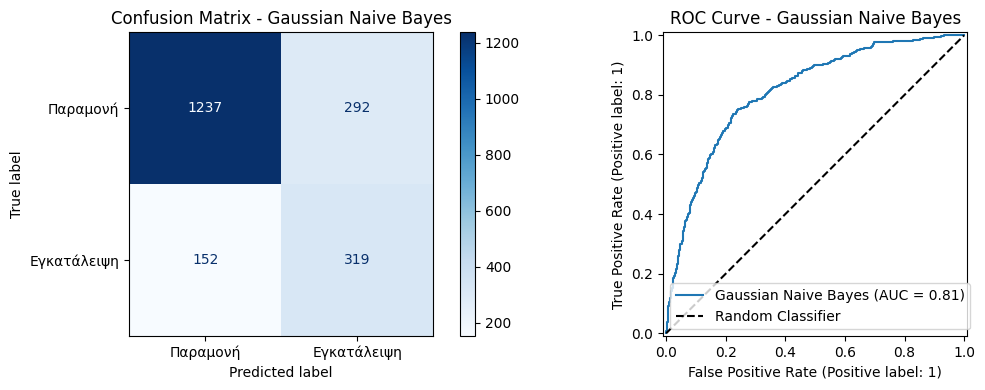

Random Forest
Accuracy : 0.7635
Precision: 0.4985
Recall   : 0.6964
F1-score : 0.5810
ROC-AUC  : 0.8099

Classification Report:
                 precision    recall  f1-score   support

   Παραμονή (0)       0.89      0.78      0.84      1529
Εγκατάλειψη (1)       0.50      0.70      0.58       471

       accuracy                           0.76      2000
      macro avg       0.70      0.74      0.71      2000
   weighted avg       0.80      0.76      0.78      2000



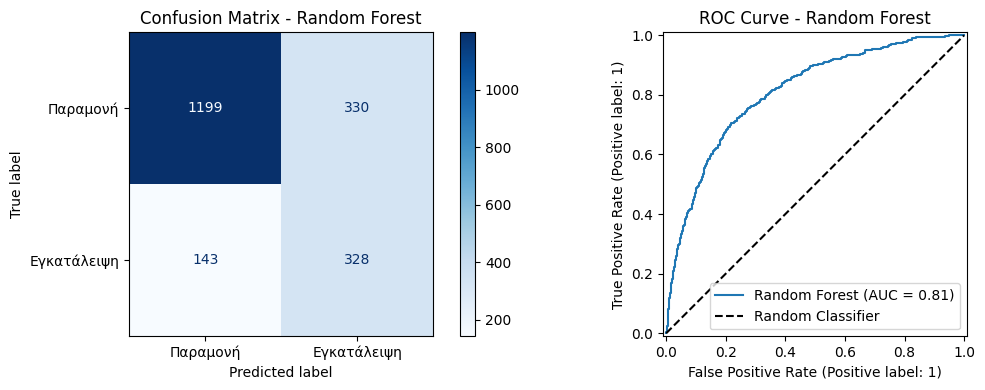

In [18]:
best_models = {
    "Logistic Regression": best_lr,
    "Gaussian Naive Bayes": best_nb,
    "Random Forest": best_rf
}

test_results = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    test_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Παραμονή (0)", "Εγκατάλειψη (1)"]
    ))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Παραμονή", "Εγκατάλειψη"],
        cmap="Blues",
        ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix - " + name)

    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=axes[1]
    )
    axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
    axes[1].set_title("ROC Curve - " + name)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 1.6 Συγκριτική Ανάλυση Αποτελεσμάτων

## Cross-validation mean και standard deviation


In [19]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []

for name, model in best_models.items():
    cv_scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=True
    )

    row = {"Μοντέλο": name}

    for metric in scoring:
        row[metric + "_mean"] = cv_scores["test_" + metric].mean()
        row[metric + "_std"] = cv_scores["test_" + metric].std()

    row["train_roc_auc_mean"] = cv_scores["train_roc_auc"].mean()
    row["test_roc_auc_mean"] = cv_scores["test_roc_auc"].mean()
    row["roc_auc_gap"] = (
        row["train_roc_auc_mean"] - row["test_roc_auc_mean"]
    )

    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).set_index("Μοντέλο")

display(cv_results_df.round(4))

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,train_roc_auc_mean,test_roc_auc_mean,roc_auc_gap
Μοντέλο,,,,,,,,,,,,,
Logistic Regression,0.7405,0.0069,0.4680,0.0087,0.7499,0.0317,0.5761,0.0135,0.8212,0.0096,0.8238,0.8212,0.0026
Gaussian Naive Bayes,0.7759,0.0064,0.5187,0.0102,0.6659,0.0302,0.5829,0.0150,0.8133,0.0083,0.8151,0.8133,0.0018
Random Forest,0.7651,0.0062,0.5008,0.0099,0.6835,0.0232,0.5779,0.0129,0.8120,0.0072,0.9058,0.8120,0.0938


# 1.6 Συγκριτικός πίνακας αποτελεσμάτων


In [20]:
comparison_rows = []

for name in best_models:
    row = {
        "Μοντέλο": name,
        "Test Accuracy": test_results[name]["Accuracy"],
        "Test Precision": test_results[name]["Precision"],
        "Test Recall": test_results[name]["Recall"],
        "Test F1-score": test_results[name]["F1-score"],
        "Test ROC-AUC": test_results[name]["ROC-AUC"],
        "CV Accuracy Mean": cv_results_df.loc[name, "accuracy_mean"],
        "CV Accuracy Std": cv_results_df.loc[name, "accuracy_std"],
        "CV ROC-AUC Mean": cv_results_df.loc[name, "roc_auc_mean"],
        "CV ROC-AUC Std": cv_results_df.loc[name, "roc_auc_std"],
        "Train-Test ROC-AUC Gap": cv_results_df.loc[name, "roc_auc_gap"]
    }

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Μοντέλο")

display(comparison_df.round(4))

,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,CV Accuracy Mean,CV Accuracy Std,CV ROC-AUC Mean,CV ROC-AUC Std,Train-Test ROC-AUC Gap
Μοντέλο,,,,,,,,,,
Logistic Regression,0.7430,0.4717,0.7622,0.5828,0.8203,0.7405,0.0069,0.8212,0.0096,0.0026
Gaussian Naive Bayes,0.7780,0.5221,0.6773,0.5896,0.8126,0.7759,0.0064,0.8133,0.0083,0.0018
Random Forest,0.7635,0.4985,0.6964,0.5810,0.8099,0.7651,0.0062,0.8120,0.0072,0.0938


## Γράφημα σύγκρισης test metrics


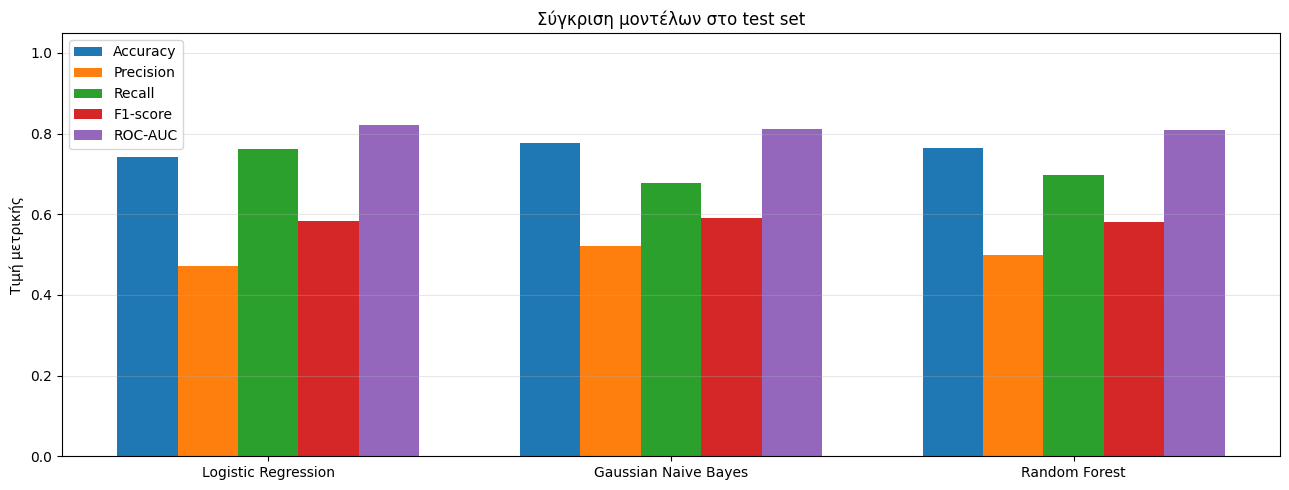

In [21]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_names = list(best_models.keys())

x = np.arange(len(model_names))
width = 0.15

plt.figure(figsize=(13, 5))

for i, metric in enumerate(metrics):
    values = [test_results[name][metric] for name in model_names]
    plt.bar(x + i * width, values, width, label=metric)

plt.xticks(
    x + width * (len(metrics) - 1) / 2,
    model_names
)

plt.ylim(0, 1.05)
plt.ylabel("Τιμή μετρικής")
plt.title("Σύγκριση μοντέλων στο test set")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## ROC curves όλων των μοντέλων


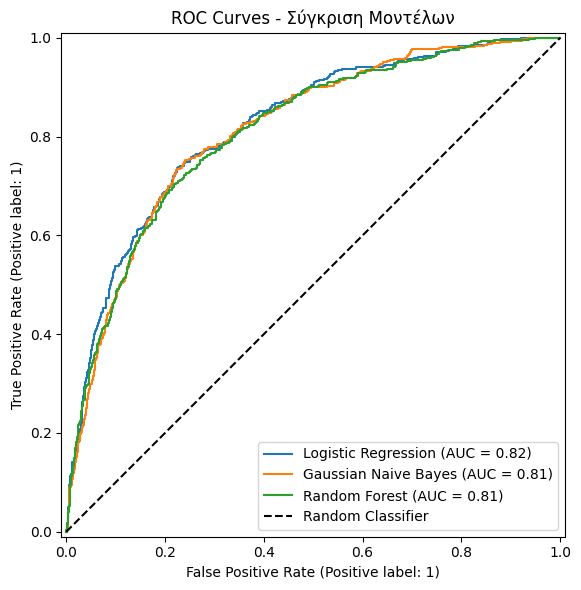

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, model in best_models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name,
        ax=ax
    )

ax.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax.set_title("ROC Curves - Σύγκριση Μοντέλων")
ax.legend()

plt.tight_layout()
plt.show()

## Σταθερότητα μοντέλων: CV ROC-AUC

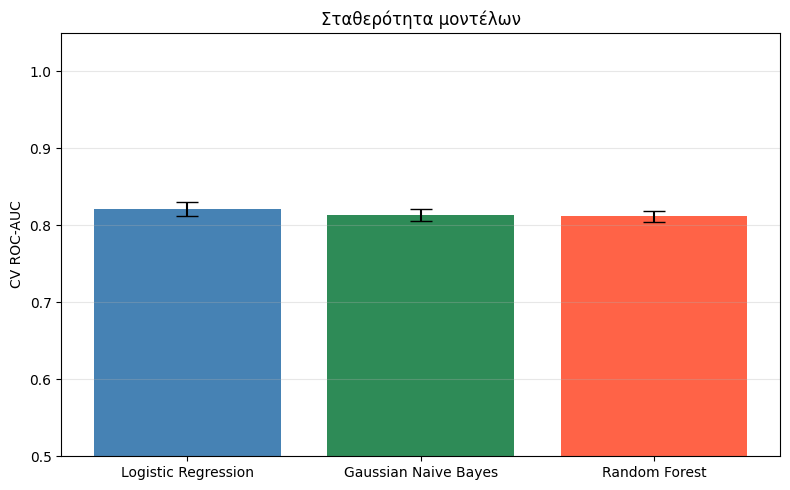

In [23]:
auc_means = comparison_df["CV ROC-AUC Mean"]
auc_stds = comparison_df["CV ROC-AUC Std"]

plt.figure(figsize=(8, 5))

plt.bar(
    auc_means.index,
    auc_means.values,
    color=["steelblue", "seagreen", "tomato"]
)

plt.errorbar(
    auc_means.index,
    auc_means.values,
    yerr=auc_stds.values,
    fmt="none",
    color="black",
    capsize=8
)

plt.ylim(0.5, 1.05)
plt.ylabel("CV ROC-AUC")
plt.title("Σταθερότητα μοντέλων")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 1.6 Έλεγχος overfitting: Train vs Test ROC-AUC


In [24]:
overfitting_rows = []

for name, model in best_models.items():
    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)

    overfitting_rows.append({
        "Μοντέλο": name,
        "Train ROC-AUC": train_auc,
        "Test ROC-AUC": test_auc,
        "Difference": train_auc - test_auc
    })

overfitting_df = pd.DataFrame(overfitting_rows).set_index("Μοντέλο")

display(overfitting_df.round(4))

,Train ROC-AUC,Test ROC-AUC,Difference
Μοντέλο,,,
Logistic Regression,0.8236,0.8203,0.0033
Gaussian Naive Bayes,0.8149,0.8126,0.0023
Random Forest,0.9022,0.8099,0.0923


## Τελική επιλογή καλύτερου μοντέλου


In [25]:
best_auc_model = comparison_df["Test ROC-AUC"].idxmax()
best_recall_model = comparison_df["Test Recall"].idxmax()
most_stable_model = comparison_df["CV ROC-AUC Std"].idxmin()
smallest_gap_model = comparison_df["Train-Test ROC-AUC Gap"].abs().idxmin()

print("Final comparative analysis")
print("=" * 70)

print("Best model by Test ROC-AUC:", best_auc_model)
print("Best model by Recall:", best_recall_model)
print("Most stable model by CV ROC-AUC std:", most_stable_model)
print("Smallest train-test ROC-AUC gap:", smallest_gap_model)

print("\nComparison table:")
display(comparison_df.round(4))



Final comparative analysis
Best model by Test ROC-AUC: Logistic Regression
Best model by Recall: Logistic Regression
Most stable model by CV ROC-AUC std: Random Forest
Smallest train-test ROC-AUC gap: Gaussian Naive Bayes

Comparison table:


,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test ROC-AUC,CV Accuracy Mean,CV Accuracy Std,CV ROC-AUC Mean,CV ROC-AUC Std,Train-Test ROC-AUC Gap
Μοντέλο,,,,,,,,,,
Logistic Regression,0.7430,0.4717,0.7622,0.5828,0.8203,0.7405,0.0069,0.8212,0.0096,0.0026
Gaussian Naive Bayes,0.7780,0.5221,0.6773,0.5896,0.8126,0.7759,0.0064,0.8133,0.0083,0.0018
Random Forest,0.7635,0.4985,0.6964,0.5810,0.8099,0.7651,0.0062,0.8120,0.0072,0.0938


## Τελικό Συμπέρασμα Συγκριτικής Ανάλυσης

Με βάση τα αποτελέσματα, το καλύτερο συνολικά μοντέλο είναι η **Logistic Regression**.

Η Logistic Regression έχει το υψηλότερο `Test ROC-AUC` (0.8203) και το υψηλότερο `Recall` για την κλάση εγκατάλειψης (0.7622). Για το συγκεκριμένο πρόβλημα, το Recall είναι ιδιαίτερα σημαντικό, επειδή ένας φοιτητής που κινδυνεύει να εγκαταλείψει και δεν εντοπίζεται αποτελεί πιο σοβαρό σφάλμα από ένα false positive.

Το Gaussian Naive Bayes έχει την υψηλότερη Accuracy (0.7780) και ελαφρώς υψηλότερο F1-score (0.5896), όμως έχει χαμηλότερο Recall (0.6773) και χαμηλότερο ROC-AUC από τη Logistic Regression.

Το Random Forest παρουσιάζει την καλύτερη σταθερότητα ως προς το `CV ROC-AUC Std`, αλλά εμφανίζει σημαντικό train-test gap περίπου 0.09, άρα υπάρχει ένδειξη υπερπροσαρμογής. Για αυτό δεν επιλέγεται ως τελικό μοντέλο, παρότι είναι ισχυρό ensemble method.

Συνεπώς, η Logistic Regression επιλέγεται ως τελικό μοντέλο επειδή συνδυάζει υψηλή γενικευτική απόδοση, υψηλό Recall για την κλάση ενδιαφέροντος, πολύ μικρό train-test gap και καλύτερη ερμηνευσιμότητα.
